# KBO 투수 피로 신호 재현 분석

이 노트북은 공개 저장소의 정본 데이터만 사용해 점수의 의미, 같은 경기 성과와의 기술적 관계, 기존 임계값의 타당성을 순서대로 확인합니다. 자동 교체 추천이나 부상 진단을 목표로 하지 않습니다.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from kbo_fatigue import (
    build_audit_metrics, correlation_summary, decile_summary,
    load_dataset, validate_dataset,
)

DATA = ROOT / 'data' / 'final' / 'fatigue_with_index.csv'

Matplotlib is building the font cache; this may take a moment.


## 1. 데이터 계약

기간·행 수·선수 수·중복 키·점수 변환을 코드로 검증합니다. 이 검사가 실패하면 뒤 분석을 진행하지 않습니다.

In [2]:
df = load_dataset(DATA)
checks = validate_dataset(df)
pd.Series(checks, name='value').to_frame()

,value
rows,17528
players,163
date_min,2020-05-05
date_max,2024-10-01
years,"[2020, 2021, 2022, 2023, 2024]"
duplicate_player_dates,0
score_min,0.005705
score_max,100.0
percentile_rank_max_error,0.0
finite_scores,True


## 2. 0–100 점수의 정체

`피로도지수_점수`가 원점수의 경험적 백분위와 정확히 같은지 확인합니다. 이 값은 확률이 아니라 현재 데이터 모집단 안의 상대 순위입니다.

In [3]:
expected = df['피로도지수'].rank(method='average', pct=True) * 100
score_check = pd.DataFrame({
    'stored_score': df['피로도지수_점수'],
    'recalculated_percentile': expected,
})
score_check['absolute_error'] = (score_check['stored_score'] - score_check['recalculated_percentile']).abs()
score_check.describe().round(6)

,stored_score,recalculated_percentile,absolute_error
count,17528.000000,17528.000000,17528.0
mean,50.002853,50.002853,0.0
std,28.868337,28.868337,0.0
min,0.005705,0.005705,0.0
25%,25.004279,25.004279,0.0
50%,50.002853,50.002853,0.0
75%,75.001426,75.001426,0.0
max,100.000000,100.000000,0.0


## 3. 같은 경기 성과와의 기술적 관계

전체 행 상관과 선수별 평균 수준을 제거한 선수 내 상관을 함께 봅니다. 점수 개발에 경기력 관련 데이터가 사용됐으므로 예측 성능이나 인과효과로 해석하지 않습니다.

In [4]:
correlations = correlation_summary(df)
correlations.round(4)

,metric,overall_r,within_player_r
0,FIP,0.4822,0.4825
1,WHIP,0.8338,0.8365
2,ERA,0.6374,0.6403
3,GS,-0.3890,-0.4507


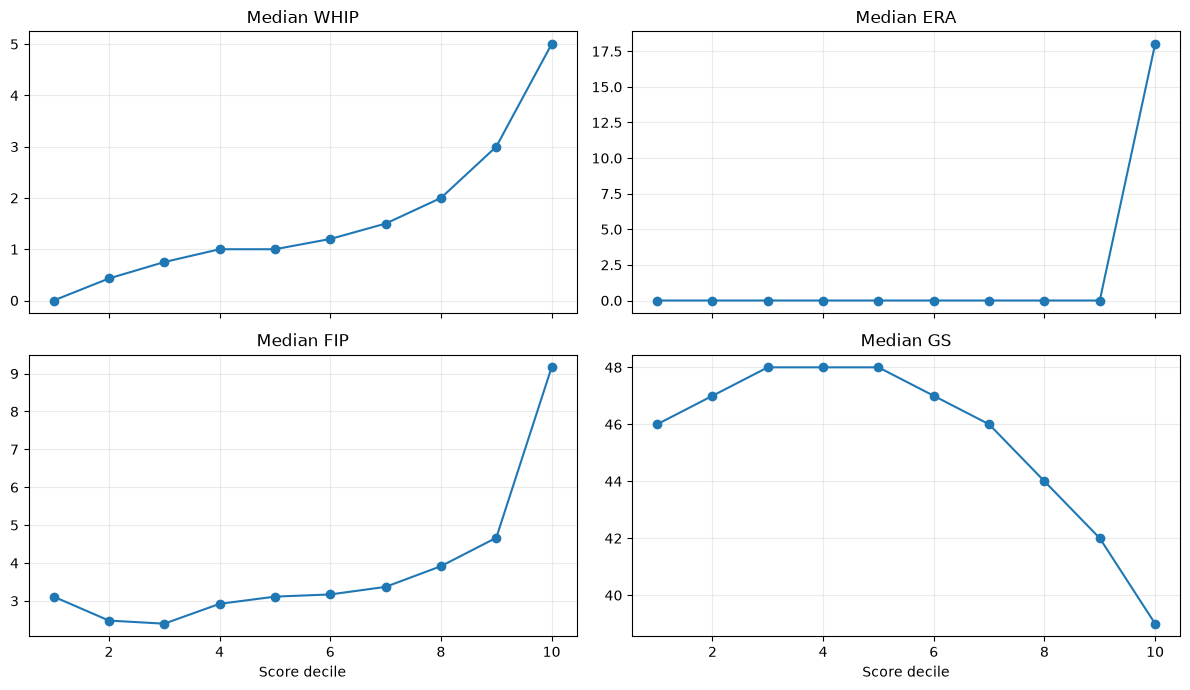

In [5]:
deciles = decile_summary(df)
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, metric in zip(axes.flat, ['WHIP', 'ERA', 'FIP', 'GS']):
    ax.plot(deciles['score_decile'], deciles[metric], marker='o')
    ax.set_title(f'Median {metric}')
    ax.grid(alpha=.25)
for ax in axes[-1]:
    ax.set_xlabel('Score decile')
plt.tight_layout()
plt.show()

## 4. 임계값 진단

저장된 점수가 `회복실패여부`와 과거 노트북의 부상 대리 라벨을 얼마나 구분하는지 ROC AUC로 확인합니다. 0.5는 무작위 순위와 같은 수준입니다.

In [6]:
metrics = build_audit_metrics(df)
pd.Series(metrics['classification_diagnostics']).to_frame('value')

,value
recovery_failure_auc,0.5143
injury_proxy_auc,0.5079
injury_proxy_definition,부상위험도가 결측이 아니고 0보다 큰 행


## 결론

- 0–100 점수는 원점수의 전체 표본 백분위다.
- 같은 경기 성과와의 관계는 강하지만, 개발·평가 표본과 변수의 순환성 때문에 미래 예측력으로 볼 수 없다.
- 회복실패와 부상 대리 라벨 AUC가 0.5에 가까워 72.6 교체 임계값과 자동 추천은 지지되지 않는다.
- 현재 결과는 과거 기록 탐색용 모니터링 신호로만 사용한다.